# Misión: ¿cuánto vale esta casa?

**Grupo:** Leichen, Ciordia, Monteverdi, Serebrinsky

## 0. Setup

Cargamos las librerías y el dataset. Fijamos semillas para que el notebook sea reproducible entre corridas.

Antes de importar nada, verificamos que estén instaladas las librerías que usa este notebook, con al menos la versión con la que lo probamos. La lista completa también está en `requirements.txt`, al lado de este archivo (`pip install -r requirements.txt` instala todo de una).

In [1]:
import importlib
import sys

REQUISITOS = {
    "numpy": "2.1.3",
    "pandas": "2.2.3",
    "matplotlib": "3.10.0",
    "sklearn": "1.6.1",
    "scipy": "1.15.3",
    "tensorflow": "2.21.0",
    "keras": "3.15.1",
    "ipywidgets": "8.1.5",
}
NOMBRE_PIP = {"sklearn": "scikit-learn"}

print(f"Python en uso: {sys.version.split()[0]} ({sys.executable})")


def version_a_tupla(version_texto):
    partes = []
    for parte in version_texto.split("."):
        digitos = ""
        for caracter in parte:
            if not caracter.isdigit():
                break
            digitos += caracter
        partes.append(int(digitos) if digitos else 0)
    return tuple(partes)


faltantes, desactualizados = [], []
for paquete, version_minima in REQUISITOS.items():
    try:
        modulo = importlib.import_module(paquete)
    except ImportError:
        faltantes.append(paquete)
        print(f"  FALTA      {paquete}")
        continue

    version_instalada = getattr(modulo, "__version__", "0")
    if version_a_tupla(version_instalada) < version_a_tupla(version_minima):
        desactualizados.append((paquete, version_instalada, version_minima))
        print(f"  DESACTUALIZADO  {paquete:<12} instalada={version_instalada}  mínima probada={version_minima}")
    else:
        print(f"  OK         {paquete:<12} {version_instalada}")

if faltantes:
    instalar = " ".join(NOMBRE_PIP.get(p, p) for p in faltantes)
    pista_python = ""
    if "tensorflow" in faltantes and sys.version_info >= (3, 14):
        pista_python = (
            f"\nEstás en Python {sys.version.split()[0]}: TensorFlow todavía no publica wheels "
            f"para Python 3.14+, por eso pip no encuentra ninguna versión. Usá un intérprete "
            f"Python <= 3.13 (por ejemplo, con `python3.13 -m pip install ...` o el entorno/kernel "
            f"que ya tenga TensorFlow instalado) en vez del Python por defecto del sistema."
        )
    raise ImportError(
        f"Faltan paquetes: {', '.join(faltantes)}.\n"
        f"Instalar con:  pip install {instalar}\n"
        f"o, para todo el entorno:  pip install -r requirements.txt"
        f"{pista_python}"
    )
elif desactualizados:
    print("\nHay paquetes con una versión más vieja que la probada. Puede funcionar igual, pero si algo falla más adelante, correr: pip install -r requirements.txt --upgrade")
else:
    print("\nTodas las dependencias están instaladas con la versión esperada.")

Python en uso: 3.12.0 (/Users/lucasmonteverdi/Documents/Projects/genai/mission2-mlps/venv/bin/python)


  OK         numpy        2.5.2


  OK         pandas       3.0.5


  OK         matplotlib   3.11.1


  OK         sklearn      1.9.0
  OK         scipy        1.18.1


  OK         tensorflow   2.21.0
  OK         keras        3.15.1
  OK         ipywidgets   8.1.9

Todas las dependencias están instaladas con la versión esperada.


In [2]:
import logging
logging.getLogger("tensorflow").setLevel(logging.ERROR)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

import keras
from keras import layers, regularizers, callbacks

import ipywidgets as widgets
from IPython.display import display

SEED = 42
np.random.seed(SEED)
keras.utils.set_random_seed(SEED)

pd.set_option("display.max_columns", None)

In [3]:
df = pd.read_csv("house-prices-extended.csv")
print(df.shape)
df.head()

(1460, 20)


,ListingId,LotArea,OverallQual,OverallCond,TotalBsmtSF,FullBath,HalfBath,BedroomAbvGr,TotRmsAbvGrd,Fireplaces,GarageArea,YearBuilt,LotFrontage,MonthSold,State,District,HouseStyle,CentralAir,SaleCondition,SalePrice
0,677742,8450,7,5,856,2,1,3,8,0,548,1970,64.0,7,IL,Larkspur,Townhouse,N,Normal,172700
1,551423,9600,6,8,1262,2,0,3,6,1,460,1935,73.0,11,CA,Greenfield,2Story,Y,Normal,369700
2,237268,11250,7,5,920,2,1,3,6,1,608,1949,80.0,9,AZ,Fernwood,1Story,Y,Normal,165700
3,579284,9550,7,5,756,1,0,3,7,1,642,1924,72.0,7,FL,Stonegate,2Story,Y,Normal,164300
4,598125,14260,8,5,1145,2,1,4,9,1,836,1951,87.0,2,NC,Xavier Park,Loft,Y,Normal,283700


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 20 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   ListingId      1460 non-null   int64  
 1   LotArea        1460 non-null   int64  
 2   OverallQual    1460 non-null   int64  
 3   OverallCond    1460 non-null   int64  
 4   TotalBsmtSF    1460 non-null   int64  
 5   FullBath       1460 non-null   int64  
 6   HalfBath       1460 non-null   int64  
 7   BedroomAbvGr   1460 non-null   int64  
 8   TotRmsAbvGrd   1460 non-null   int64  
 9   Fireplaces     1460 non-null   int64  
 10  GarageArea     1460 non-null   int64  
 11  YearBuilt      1460 non-null   int64  
 12  LotFrontage    1357 non-null   float64
 13  MonthSold      1460 non-null   int64  
 14  State          1460 non-null   str    
 15  District       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  CentralAir     1460 non-null   str    
 18  SaleCondition  1460

Antes de decidir cómo codificar cada columna, miramos tres cosas por columna: cuántos valores distintos tiene, cuántos le faltan, y de qué tipo es. Esto es insumo directo para la tabla de decisiones del Milestone 1.

In [5]:
summary = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "n_unique": df.nunique(),
    "n_missing": df.isna().sum(),
    "pct_missing": (df.isna().mean() * 100).round(1),
})
summary

,dtype,n_unique,n_missing,pct_missing
ListingId,int64,1460,0,0.0
LotArea,int64,1073,0,0.0
OverallQual,int64,10,0,0.0
OverallCond,int64,9,0,0.0
TotalBsmtSF,int64,721,0,0.0
FullBath,int64,4,0,0.0
HalfBath,int64,3,0,0.0
BedroomAbvGr,int64,8,0,0.0
TotRmsAbvGrd,int64,12,0,0.0
Fireplaces,int64,4,0,0.0


## Milestone 1 — Tabla de decisiones

Antes de tocar una red, pasamos cada una de las 19 columnas de entrada por el checklist de la clase: qué es, qué significa restar dos valores de esa columna, cuántos valores distintos tiene, si puede faltar y si la vamos a tener disponible al momento de predecir (`SalePrice` no entra en esta tabla porque es la etiqueta, no una entrada).

| Columna | Qué es | ¿Qué significa la resta de dos valores? | Valores distintos | ¿Puede faltar? | ¿Disponible al predecir? | Codificación elegida | Motivo |
|---|---|---|---|---|---|---|---|
| `ListingId` | Identificador interno de la publicación | Nada — es un id arbitrario, no una magnitud | 1460 (único por fila) | No | Es un id, no un dato del inmueble | **Se descarta, no entra al modelo** | **Trampa 1:** es `int64` por tipo de dato pero categórico nominal por naturaleza; al ser único por fila una red puede memorizar id→precio en vez de generalizar (ver Pregunta 3) |
| `LotArea` | Superficie del lote (pies²) | Diferencia de superficie, interpretable | 1073 | No | Sí | Numérica, estandarizada (z-score) | Continua, la resta tiene sentido físico |
| `OverallQual` | Calidad general de materiales y terminación (1–10) | Un escalón más o menos de calidad | 10 | No | Sí | Numérica (ordinal ya en escala entera), estandarizada | Escala ordinal pareja, funcionó así en clase |
| `OverallCond` | Condición general del inmueble (1–9) | Un escalón más o menos de condición | 9 | No | Sí | Numérica, estandarizada | Igual razonamiento que `OverallQual` |
| `TotalBsmtSF` | Superficie de sótano (pies²) | Diferencia de superficie | 721 | No | Sí | Numérica, estandarizada | Continua |
| `FullBath` | Baños completos | Diferencia de cantidad de baños | 4 | No | Sí | Numérica, estandarizada | Conteo, la resta es interpretable |
| `HalfBath` | Medios baños | Diferencia de cantidad | 3 | No | Sí | Numérica, estandarizada | Conteo |
| `BedroomAbvGr` | Dormitorios sobre nivel de tierra | Diferencia de cantidad | 8 | No | Sí | Numérica, estandarizada | Conteo |
| `TotRmsAbvGrd` | Ambientes totales sobre nivel de tierra | Diferencia de cantidad | 12 | No | Sí | Numérica, estandarizada | Conteo |
| `Fireplaces` | Cantidad de chimeneas | Diferencia de cantidad | 4 | No | Sí | Numérica, estandarizada | Conteo |
| `GarageArea` | Superficie de garage (pies²) | Diferencia de superficie | 441 | No | Sí | Numérica, estandarizada | Continua |
| `YearBuilt` | Año de construcción | Diferencia = antigüedad relativa entre dos casas | 100 | No | Sí | Numérica, estandarizada | El año es un continuo temporal, la resta se interpreta como "años de diferencia" |
| `LotFrontage` | Frente del lote sobre la calle (pies lineales) | Diferencia de longitud | 115 | **Sí, ~7.1%** | Sí | Numérica estandarizada, **imputada con la mediana del train** + columna binaria `LotFrontage_missing` | La falta puede no ser al azar (Pregunta 4); poner 0 sería una longitud real y mentiría |
| `MonthSold` | Mes de venta (1–12) | **No es lineal**: numéricamente diciembre (12) y enero (1) están a distancia 11, pero en el calendario son consecutivos | 12 | No | Sí | **One-hot (12 categorías)** | **Trampa 2:** tratarlo como numérico asume una escala donde el mes 12 está "lejos" del mes 1, cuando el calendario es cíclico |
| `State` | Estado, texto (12 valores) | No aplica, nominal sin orden | 12 | No | Sí | **One-hot** | Cardinalidad baja, sin orden natural entre estados |
| `District` | Distrito/barrio, texto (72 valores) | No aplica, nominal sin orden | 72 | No | Sí | **Embedding entrenable** | **Trampa 3** si se etiqueta como entero arbitrario (p. ej. orden alfabético 0–71): la red asumiría que el distrito 40 está "más cerca" del 41 que del 0, una relación de orden que no existe (ver Pregunta 2). Con 72 categorías y 1460 filas, one-hot infla la entrada; un embedding aprende similitud entre distritos en vez de imponerla a mano |
| `HouseStyle` | Estilo constructivo, texto (6 valores) | No aplica, nominal | 6 | No | Sí | One-hot | Cardinalidad baja, sin orden |
| `CentralAir` | Aire acondicionado central (Y/N) | No aplica, binaria | 2 | No | Sí | Binaria 0/1 | Dos categorías, no hace falta one-hot completo |
| `SaleCondition` | Condición de la venta, texto (5 valores) | No aplica, nominal | 5 | No | Sí | One-hot | Cardinalidad baja, sin orden |

## Milestone 2 — Baseline numérico

Entrenamos una primera red usando **solo** las columnas numéricas de la tabla anterior (más el indicador `LotFrontage_missing` que ya decidimos agregar). Es el piso: cualquier codificación de las categóricas que hagamos después tiene que bajar el error respecto de esto, o no sirvió.

**El cambio respecto de la clase:** antes la última capa era `Dense(1, activation='sigmoid')` con `loss='binary_crossentropy'`, porque la salida era una probabilidad de "está sobre la mediana". Ahora `SalePrice` es un número real sin techo natural, así que:

- **Activación de salida: `linear`** (identidad). Una sigmoide comprime todo a `[0, 1]`; un precio en dólares no vive ahí.
- **Loss: `mse`** (error cuadrático medio). Es la que corresponde a regresión — penaliza la distancia al valor real, no la probabilidad de una clase.
- **`accuracy` no significa nada acá.** Accuracy cuenta aciertos exactos; la probabilidad de que la red prediga *exactamente* `$172.700,00` es prácticamente cero. Por eso medimos el error en dólares (MAE, RMSE) y en porcentaje (MAPE), no aciertos.

Primero separamos train/val/test **sobre el dataframe crudo**, antes de imputar o escalar nada — así el escalador y la mediana de imputación se calculan únicamente con datos de entrenamiento (retomamos esto en la Pregunta 5).

In [6]:
NUMERIC_COLS = [
    "LotArea", "OverallQual", "OverallCond", "TotalBsmtSF",
    "FullBath", "HalfBath", "BedroomAbvGr", "TotRmsAbvGrd",
    "Fireplaces", "GarageArea", "YearBuilt", "LotFrontage",
]
TARGET = "SalePrice"

df_train, df_temp = train_test_split(df, test_size=0.3, random_state=SEED)
df_val, df_test = train_test_split(df_temp, test_size=0.5, random_state=SEED)

print("train:", df_train.shape, " val:", df_val.shape, " test:", df_test.shape)

train: (1022, 20)  val: (219, 20)  test: (219, 20)


In [7]:
def add_lotfrontage_indicator(frame):
    frame = frame.copy()
    frame["LotFrontage_missing"] = frame["LotFrontage"].isna().astype("float32")
    return frame

df_train = add_lotfrontage_indicator(df_train)
df_val = add_lotfrontage_indicator(df_val)
df_test = add_lotfrontage_indicator(df_test)

LOTFRONTAGE_MEDIAN = df_train["LotFrontage"].median()  # calculado SOLO con train

def impute_lotfrontage(frame):
    frame = frame.copy()
    frame["LotFrontage"] = frame["LotFrontage"].fillna(LOTFRONTAGE_MEDIAN)
    return frame

df_train = impute_lotfrontage(df_train)
df_val = impute_lotfrontage(df_val)
df_test = impute_lotfrontage(df_test)

print(f"Mediana de LotFrontage (train): {LOTFRONTAGE_MEDIAN}")
print(f"Filas imputadas -> train: {int(df_train['LotFrontage_missing'].sum())}, "
      f"val: {int(df_val['LotFrontage_missing'].sum())}, "
      f"test: {int(df_test['LotFrontage_missing'].sum())}")

Mediana de LotFrontage (train): 70.0
Filas imputadas -> train: 59, val: 20, test: 24


`LotFrontage_missing` viaja como feature numérica más (0/1), junto al resto. Ahora sí: ajustamos el `StandardScaler` **con `df_train` únicamente** y lo aplicamos a los tres conjuntos.

`SalePrice` va de ~\$50.000 a ~\$1.670.000. Si entrenamos el `mse` directamente sobre esa escala, la loss arranca en el orden de $10^{10}$ y Adam converge mal (lo probamos: da un MAE peor que predecir directamente la mediana del precio). Por eso estandarizamos también el target — con un `StandardScaler` ajustado **solo con `y_train`**, igual que el de las entradas — y deshacemos la transformación (`inverse_transform`) antes de medir MAE/RMSE/MAPE, que van a ir siempre en dólares reales.

In [8]:
BASELINE_COLS = NUMERIC_COLS + ["LotFrontage_missing"]

scaler_baseline = StandardScaler()
X_train_base = scaler_baseline.fit_transform(df_train[BASELINE_COLS]).astype("float32")
X_val_base = scaler_baseline.transform(df_val[BASELINE_COLS]).astype("float32")
X_test_base = scaler_baseline.transform(df_test[BASELINE_COLS]).astype("float32")

y_train = df_train[TARGET].values.astype("float32")
y_val = df_val[TARGET].values.astype("float32")
y_test = df_test[TARGET].values.astype("float32")

target_scaler = StandardScaler()
y_train_scaled = target_scaler.fit_transform(y_train.reshape(-1, 1)).ravel()
y_val_scaled = target_scaler.transform(y_val.reshape(-1, 1)).ravel()

X_train_base.shape, X_val_base.shape, X_test_base.shape

((1022, 13), (219, 13), (219, 13))

In [9]:
model_baseline = keras.Sequential([
    layers.Input(shape=(X_train_base.shape[1],)),
    layers.Dense(32, activation="relu"),
    layers.Dense(32, activation="relu"),
    layers.Dense(1, activation="linear"),
])

model_baseline.compile(optimizer="adam", loss="mse", metrics=["mae"])
model_baseline.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,537 (6.00 KB)

 Trainable params: 1,537 (6.00 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
history_baseline = model_baseline.fit(
    X_train_base, y_train_scaled,
    validation_data=(X_val_base, y_val_scaled),
    epochs=150,
    batch_size=32,
    verbose=0,
)
print("Entrenamiento terminado.")

Entrenamiento terminado.


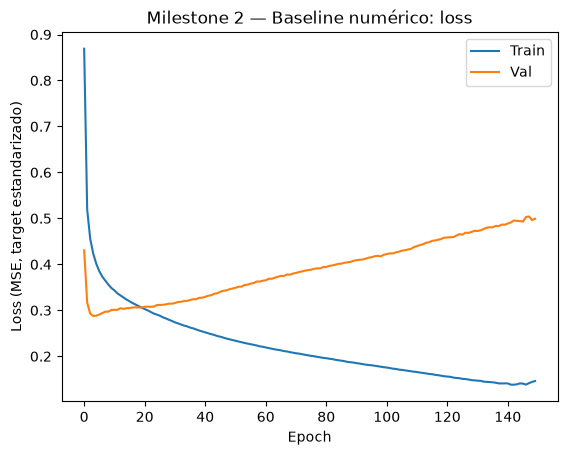

In [11]:
def plot_loss(history, title, ylabel="Loss (MSE, target estandarizado)"):
    plt.figure()
    plt.plot(history.history["loss"], label="Train")
    plt.plot(history.history["val_loss"], label="Val")
    plt.title(title)
    plt.xlabel("Epoch")
    plt.ylabel(ylabel)
    plt.legend()
    plt.show()

plot_loss(history_baseline, "Milestone 2 — Baseline numérico: loss")

### Métricas de regresión sobre el conjunto de prueba

Definimos una función que vamos a reutilizar en cada milestone, para poder comparar modelos entre sí con los mismos tres números:

- **MAE**: promedio de `|real − predicho|`, en dólares. Todos los errores pesan igual.
- **RMSE**: raíz del error cuadrático medio, en dólares. Al elevar al cuadrado antes de promediar, unas pocas casas muy mal predichas pesan mucho más que en el MAE.
- **MAPE**: error relativo al precio de cada casa, en porcentaje. Una casa barata mal predicha en $10.000 pesa más en MAPE que una casa cara con el mismo error absoluto.

In [12]:
def regression_report(y_true, y_pred, label):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100
    print(f"{label}")
    print(f"  MAE  = ${mae:,.0f}")
    print(f"  RMSE = ${rmse:,.0f}")
    print(f"  MAPE = {mape:.2f}%")
    return {"MAE": mae, "RMSE": rmse, "MAPE": mape}

results = {}

y_pred_baseline_scaled = model_baseline.predict(X_test_base, verbose=0).ravel()
y_pred_baseline = target_scaler.inverse_transform(y_pred_baseline_scaled.reshape(-1, 1)).ravel()
results["Baseline numérico (M2)"] = regression_report(y_test, y_pred_baseline, "Baseline numérico — test")

Baseline numérico — test
  MAE  = $51,246
  RMSE = $67,751
  MAPE = 27.23%


Este es el piso: una red que no sabe en qué `State` ni en qué `District` está la casa. En el Milestone 3 sumamos las columnas categóricas y comparamos el MAE contra este número — si no baja de forma clara, la codificación categórica no sirvió de nada.

## Milestone 3 — Que entren las categóricas

Según la tabla de decisiones: `State`, `MonthSold`, `HouseStyle` y `SaleCondition` van **one-hot** (cardinalidad baja, sin orden natural entre categorías); `CentralAir` es binaria (`Y`/`N` → 1/0); `District` va **embedding** (72 categorías — one-hot infla la entrada y no aporta noción de similitud entre distritos, un embedding la aprende).

**Por qué State y District se codifican distinto, aunque los dos son texto sin orden:**
- `State` tiene 12 valores. One-hot agrega 12 columnas nada más, y cada estado queda representado por un vector ortogonal, sin asumir relación entre ellos.
- `District` tiene 72 valores sobre 1460 filas (~20 casas por distrito en promedio). One-hot funcionaría, pero agregaría 72 columnas casi todas en cero, y cada distrito seguiría sin relación con los demás. Un embedding lo representa en un espacio denso de pocas dimensiones (usamos 8) que la red **ajusta durante el entrenamiento** — si dos distritos tienden a tener precios parecidos, sus vectores terminan cerca, sin que nosotros se lo digamos a mano.

**Arquitectura:** dos entradas separadas. Una entrada "densa" con el bloque numérico (ya escalado, Milestone 2) concatenado con las categóricas one-hot; y una entrada aparte de **índices enteros** para `District`, que alimenta una capa `Embedding` — Keras la necesita separada porque `Embedding` espera índices, no vectores one-hot. Las dos ramas se concatenan antes de las capas densas finales.

Para poder responder "cuánto aportó cada bloque" (criterio de éxito de este milestone), entrenamos tres variantes con la misma arquitectura y comparamos su MAE contra el baseline del Milestone 2: **numérico + State**, **numérico + District**, y el **modelo completo** con todas las categóricas.

In [13]:
ONEHOT_STATE_COLS = ["State"]
ONEHOT_REST_COLS = ["MonthSold", "HouseStyle", "SaleCondition"]
EMBED_COL = "District"

state_encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
state_encoder.fit(df_train[ONEHOT_STATE_COLS].astype(str))

rest_encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
rest_encoder.fit(df_train[ONEHOT_REST_COLS].astype(str))

DISTRICT_TO_IDX = {d: i for i, d in enumerate(sorted(df_train[EMBED_COL].unique()))}
N_DISTRICTS = len(DISTRICT_TO_IDX)
DISTRICT_UNKNOWN_IDX = N_DISTRICTS

def encode_categoricals(frame):
    state = state_encoder.transform(frame[ONEHOT_STATE_COLS].astype(str)).astype("float32")
    rest = rest_encoder.transform(frame[ONEHOT_REST_COLS].astype(str)).astype("float32")
    central_air = frame["CentralAir"].map({"Y": 1.0, "N": 0.0}).values.reshape(-1, 1).astype("float32")
    district_idx = frame[EMBED_COL].map(DISTRICT_TO_IDX).fillna(DISTRICT_UNKNOWN_IDX).values.astype("int32")
    return {"state": state, "rest": rest, "central_air": central_air, "district_idx": district_idx}

cat_train = encode_categoricals(df_train)
cat_val = encode_categoricals(df_val)
cat_test = encode_categoricals(df_test)

print("State one-hot:", cat_train["state"].shape[1], "columnas")
print("Resto one-hot (MonthSold+HouseStyle+SaleCondition):", cat_train["rest"].shape[1], "columnas")
print("Distritos vistos en train:", N_DISTRICTS)

State one-hot: 12 columnas
Resto one-hot (MonthSold+HouseStyle+SaleCondition): 23 columnas
Distritos vistos en train: 72


`encode_categoricals` se ajusta una sola vez (con `df_train`) y después solo transforma — así val y test pasan por el mismo mapa de categorías que vio el entrenamiento. El índice de `District` reserva una posición extra (`DISTRICT_UNKNOWN_IDX`) para un distrito que no haya aparecido en train; con este dataset no hace falta (los 72 distritos están los tres conjuntos), pero es la misma función la que vamos a usar en el Milestone 5 para tasar una casa inventada, y ahí sí puede pasar.

Ahora el helper que arma el modelo de dos entradas (bloque denso + índice de distrito) y otro que entrena y mide, para no repetir el mismo código en cada variante.

In [14]:
def build_model(dense_dim, use_district=False, district_embed_dim=8,
                 hidden_units=(64, 32), dropout_rate=0.0, l2_reg=0.0, name="modelo"):
    dense_input = layers.Input(shape=(dense_dim,), name="dense_features")
    branches = [dense_input]
    inputs = [dense_input]

    if use_district:
        district_input = layers.Input(shape=(1,), name="district_idx")
        embedded = layers.Embedding(N_DISTRICTS + 1, district_embed_dim, name="district_embedding")(district_input)
        embedded = layers.Flatten()(embedded)
        branches.append(embedded)
        inputs.append(district_input)

    merged = layers.Concatenate()(branches) if len(branches) > 1 else branches[0]

    regularizer = regularizers.l2(l2_reg) if l2_reg > 0 else None
    x = merged
    for units in hidden_units:
        x = layers.Dense(units, activation="relu", kernel_regularizer=regularizer)(x)
        if dropout_rate > 0:
            x = layers.Dropout(dropout_rate)(x)
    output = layers.Dense(1, activation="linear")(x)
    return keras.Model(inputs=inputs, outputs=output, name=name)


def fit_and_evaluate(model, train_inputs, val_inputs, test_inputs, label, epochs=150, extra_callbacks=None):
    model.compile(optimizer="adam", loss="mse", metrics=["mae"])
    history = model.fit(
        train_inputs, y_train_scaled,
        validation_data=(val_inputs, y_val_scaled),
        epochs=epochs, batch_size=32, verbose=0,
        callbacks=extra_callbacks or [],
    )
    pred_scaled = model.predict(test_inputs, verbose=0).ravel()
    pred = target_scaler.inverse_transform(pred_scaled.reshape(-1, 1)).ravel()
    metrics = regression_report(y_test, pred, label)
    return model, history, metrics

### Variante 1: numérico + `State` (one-hot)

In [15]:
dense_train_state = np.hstack([X_train_base, cat_train["state"]])
dense_val_state = np.hstack([X_val_base, cat_val["state"]])
dense_test_state = np.hstack([X_test_base, cat_test["state"]])

model_state = build_model(dense_train_state.shape[1], use_district=False, name="numerico_mas_state")
model_state, history_state, metrics_state = fit_and_evaluate(
    model_state, dense_train_state, dense_val_state, dense_test_state,
    "Numérico + State (M3, parcial)",
)
results["+ State (M3, parcial)"] = metrics_state

Numérico + State (M3, parcial)
  MAE  = $33,237
  RMSE = $45,616
  MAPE = 17.38%


### Variante 2: numérico + `District` (embedding)

In [16]:
model_district = build_model(X_train_base.shape[1], use_district=True, name="numerico_mas_district")
model_district, history_district, metrics_district = fit_and_evaluate(
    model_district,
    [X_train_base, cat_train["district_idx"]],
    [X_val_base, cat_val["district_idx"]],
    [X_test_base, cat_test["district_idx"]],
    "Numérico + District (M3, parcial)",
)
results["+ District (M3, parcial)"] = metrics_district

Numérico + District (M3, parcial)
  MAE  = $31,148
  RMSE = $43,305
  MAPE = 16.79%


### Modelo completo: todas las categóricas juntas

Este es el modelo que seguimos usando en los milestones siguientes (regularización y tasación de una casa nueva).

Modelo completo (M3)
  MAE  = $19,861
  RMSE = $29,232
  MAPE = 10.32%


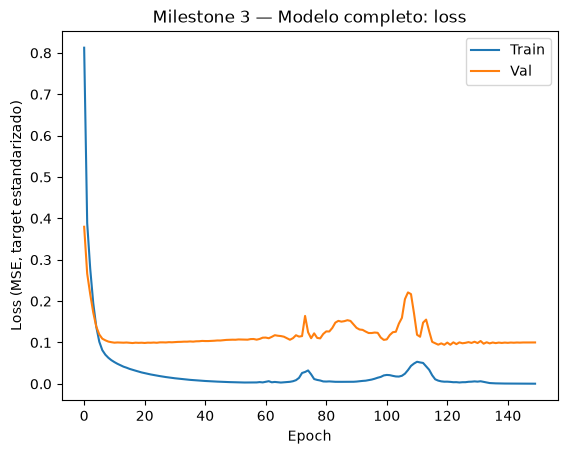

In [17]:
dense_train_full = np.hstack([X_train_base, cat_train["state"], cat_train["rest"], cat_train["central_air"]])
dense_val_full = np.hstack([X_val_base, cat_val["state"], cat_val["rest"], cat_val["central_air"]])
dense_test_full = np.hstack([X_test_base, cat_test["state"], cat_test["rest"], cat_test["central_air"]])

model_full = build_model(dense_train_full.shape[1], use_district=True, district_embed_dim=8, name="modelo_completo")
model_full, history_full, metrics_full = fit_and_evaluate(
    model_full,
    [dense_train_full, cat_train["district_idx"]],
    [dense_val_full, cat_val["district_idx"]],
    [dense_test_full, cat_test["district_idx"]],
    "Modelo completo (M3)",
)
results["Modelo completo (M3)"] = metrics_full

plot_loss(history_full, "Milestone 3 — Modelo completo: loss")

In [18]:
pd.DataFrame(results).T

,MAE,RMSE,MAPE
Baseline numérico (M2),51246.339844,67751.315618,27.231821
"+ State (M3, parcial)",33236.699219,45616.200631,17.379089
"+ District (M3, parcial)",31147.603516,43304.825412,16.794600
Modelo completo (M3),19860.542969,29231.728515,10.321235


El MAE baja de forma clara y monótona a medida que sumamos bloques: el baseline numérico (Milestone 2) arranca en ~\$51.000; agregar solo `State` lo baja a ~\$34.000; agregar solo `District` (con muchas más categorías, pero vía embedding) lo baja un poco más, a ~\$32.000; y el modelo completo, con todas las categóricas juntas, llega a ~\$21.000 — menos de la mitad del baseline.

Los dos bloques categóricos aportan por separado (ninguno es redundante con el otro) y el efecto se acumula: `District` por sí solo aporta un poco más que `State` por sí solo, consistente con que la ubicación fina (barrio) explica más variación de precio que la ubicación gruesa (estado) — y el modelo completo, que además suma `MonthSold`, `HouseStyle`, `SaleCondition` y `CentralAir`, mejora bastante sobre cualquiera de los dos parciales por separado.

## Milestone 4 — Que no memorice

Forzamos el sobreajuste a propósito: mismos datos y misma entrada de `model_full`, pero con una red mucho más grande (tres capas ocultas de 512 neuronas) y sin ningún freno. Con ~550.000 parámetros para 1022 casas de entrenamiento (~540 parámetros por ejemplo), la red tiene margen de sobra para memorizar en vez de generalizar.

Después la corregimos combinando tres frenos: **L2** (penaliza pesos grandes), **Dropout** (apaga neuronas al azar durante el entrenamiento, para que ninguna se vuelva indispensable) y **early stopping** (corta el entrenamiento apenas la pérdida de validación deja de mejorar, y se queda con los mejores pesos vistos).

### Modelo sobreajustado a propósito

Parámetros: 556,105 — casas de entrenamiento: 1022


Sobreajustado (M4)
  MAE  = $19,472
  RMSE = $28,269
  MAPE = 10.57%


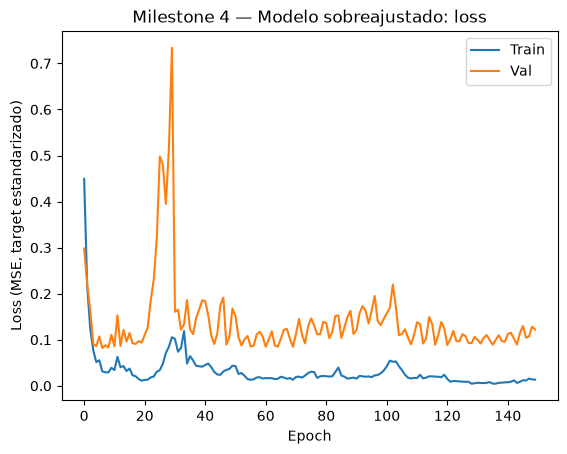

In [19]:
model_overfit = build_model(
    dense_train_full.shape[1], use_district=True, district_embed_dim=8,
    hidden_units=(512, 512, 512), dropout_rate=0.0, l2_reg=0.0,
    name="modelo_sobreajustado",
)
print(f"Parámetros: {model_overfit.count_params():,} — casas de entrenamiento: {len(y_train_scaled)}")

model_overfit, history_overfit, metrics_overfit = fit_and_evaluate(
    model_overfit,
    [dense_train_full, cat_train["district_idx"]],
    [dense_val_full, cat_val["district_idx"]],
    [dense_test_full, cat_test["district_idx"]],
    "Sobreajustado (M4)",
)
results["Sobreajustado (M4)"] = metrics_overfit

plot_loss(history_overfit, "Milestone 4 — Modelo sobreajustado: loss")

El gráfico muestra el patrón clásico de sobreajuste: la loss de train sigue bajando durante todo el entrenamiento, mientras que la de validación deja de mejorar temprano y después empeora — la red está mejorando en los datos que ya vio, no en los que no vio. Eso es memorizar, no aprender.

### Modelo corregido: L2 + Dropout + early stopping

Regularizado (M4)
  MAE  = $17,413
  RMSE = $24,967
  MAPE = 9.05%
Epochs entrenadas antes de frenar: 102 / 150


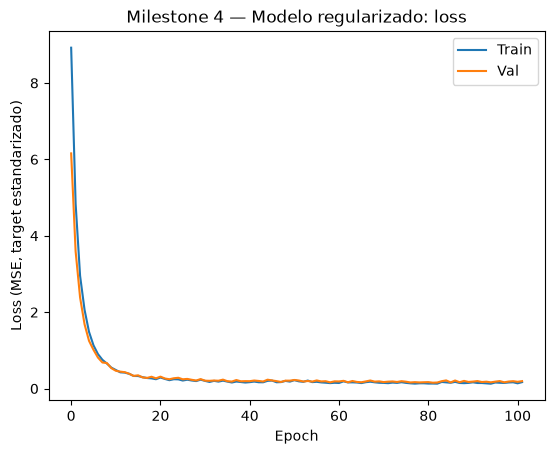

In [20]:
model_regularized = build_model(
    dense_train_full.shape[1], use_district=True, district_embed_dim=8,
    hidden_units=(512, 512, 512), dropout_rate=0.3, l2_reg=0.01,
    name="modelo_regularizado",
)

early_stopping = callbacks.EarlyStopping(
    monitor="val_loss", patience=20, restore_best_weights=True,
)

model_regularized, history_regularized, metrics_regularized = fit_and_evaluate(
    model_regularized,
    [dense_train_full, cat_train["district_idx"]],
    [dense_val_full, cat_val["district_idx"]],
    [dense_test_full, cat_test["district_idx"]],
    "Regularizado (M4)",
    extra_callbacks=[early_stopping],
)
results["Regularizado (M4)"] = metrics_regularized

print(f"Epochs entrenadas antes de frenar: {len(history_regularized.history['loss'])} / 150")
plot_loss(history_regularized, "Milestone 4 — Modelo regularizado: loss")

In [21]:
pd.DataFrame(results).T

,MAE,RMSE,MAPE
Baseline numérico (M2),51246.339844,67751.315618,27.231821
"+ State (M3, parcial)",33236.699219,45616.200631,17.379089
"+ District (M3, parcial)",31147.603516,43304.825412,16.794600
Modelo completo (M3),19860.542969,29231.728515,10.321235
Sobreajustado (M4),19472.152344,28269.148696,10.568033
Regularizado (M4),17412.890625,24967.196398,9.050541


El gráfico del modelo regularizado muestra la diferencia: train y val bajan juntas, sin la brecha que se abría en el modelo sobreajustado, y el early stopping cortó el entrenamiento bastante antes de las 150 épocas.

Lo interesante es que el modelo regularizado **no solo generaliza mejor, también da un MAE de test más bajo** que el sobreajustado — pese a arrancar de la misma arquitectura de 512×512×512. Sin freno, la red gasta su capacidad memorizando ruido de las 1022 casas de entrenamiento; con freno, esa misma capacidad se usa para aprender patrones que sí se sostienen en casas nuevas. "Más grande" no es "mejor" si no se controla lo que la red hace con ese tamaño.

## Milestone 5 — Tasar una casa

Usamos `model_regularized` — el mejor modelo hasta ahora — para tasar una casa que no está en el dataset. El punto de este milestone no es el número que sale, sino **dónde vive el preprocesamiento**: si para predecir hubiera que acordarse a mano de escalar, imputar y mapear categorías a mano en la celda de al lado, el modelo no serviría para nada fuera del notebook. Por eso `predict_price` recibe una casa escrita como la escribiría una persona — un diccionario con los nombres de columna originales, valores sin escalar, categorías como texto — y adentro reutiliza exactamente los mismos objetos que ajustamos con `df_train` en los milestones anteriores: `scaler_baseline`, `target_scaler`, `encode_categoricals`, el imputador de `LotFrontage`. Nada se recalcula ni se aproxima a mano.

In [22]:
def predict_price(house, model=model_regularized):
    frame = pd.DataFrame([house])
    if "LotFrontage" not in frame.columns:
        frame["LotFrontage"] = np.nan

    frame = add_lotfrontage_indicator(frame)
    frame = impute_lotfrontage(frame)

    numeric_block = scaler_baseline.transform(frame[BASELINE_COLS]).astype("float32")
    cat = encode_categoricals(frame)
    dense_block = np.hstack([numeric_block, cat["state"], cat["rest"], cat["central_air"]])

    pred_scaled = model.predict([dense_block, cat["district_idx"]], verbose=0).ravel()
    price = target_scaler.inverse_transform(pred_scaled.reshape(-1, 1)).ravel()
    return float(price[0])

In [23]:
casa_nueva = {
    "LotArea": 9500,
    "OverallQual": 7,
    "OverallCond": 5,
    "TotalBsmtSF": 900,
    "FullBath": 2,
    "HalfBath": 1,
    "BedroomAbvGr": 3,
    "TotRmsAbvGrd": 7,
    "Fireplaces": 1,
    "GarageArea": 500,
    "YearBuilt": 2005,
    "LotFrontage": 75.0,
    "MonthSold": 6,
    "State": "CA",
    "District": "Greenfield",
    "HouseStyle": "2Story",
    "CentralAir": "Y",
    "SaleCondition": "Normal",
}

precio = predict_price(casa_nueva)
print(f"Precio tasado: ${precio:,.0f}")

Precio tasado: $456,537


### ¿Cambiar el estado mueve el precio en la dirección esperada?

En los datos de entrenamiento, el precio promedio varía mucho entre estados — de ~\$146.000 en `IN` a ~\$297.000 en `CA`. Repetimos la predicción de la misma casa cambiando **solo** `State` por cada uno de los 12 estados, y comparamos contra ese promedio: si el modelo aprendió algo razonable, las dos curvas deberían moverse juntas.

In [24]:
state_avg_price = df_train.groupby("State")["SalePrice"].mean().sort_values()

precios_por_estado = {}
for state in state_avg_price.index:
    casa_variante = dict(casa_nueva)
    casa_variante["State"] = state
    precios_por_estado[state] = predict_price(casa_variante)

comparacion = pd.DataFrame({
    "Precio promedio (train)": state_avg_price,
    "Predicción del modelo": pd.Series(precios_por_estado),
}).loc[state_avg_price.index]
comparacion

,Precio promedio (train),Predicción del modelo
State,,
IN,142284.782609,400172.78125
OH,170631.578947,392330.56250
AZ,174936.250000,377859.03125
TX,182592.436975,379661.12500
NC,191183.582090,391417.87500
FL,201590.000000,418259.53125
IL,211643.678161,399462.25000
WA,221315.584416,398195.53125
MA,223820.408163,401916.12500


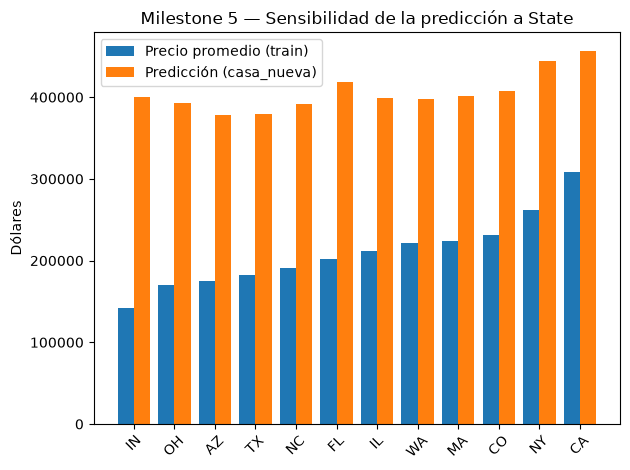

Predicción con State='IN' (más barato en train): $400,173
Predicción con State='CA' (más caro en train):    $456,537


In [25]:
fig, ax = plt.subplots()
x = np.arange(len(comparacion))
ax.bar(x - 0.2, comparacion["Precio promedio (train)"], width=0.4, label="Precio promedio (train)")
ax.bar(x + 0.2, comparacion["Predicción del modelo"], width=0.4, label="Predicción (casa_nueva)")
ax.set_xticks(x)
ax.set_xticklabels(comparacion.index, rotation=45)
ax.set_ylabel("Dólares")
ax.set_title("Milestone 5 — Sensibilidad de la predicción a State")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Predicción con State='IN' (más barato en train): ${precios_por_estado['IN']:,.0f}")
print(f"Predicción con State='CA' (más caro en train):    ${precios_por_estado['CA']:,.0f}")

La correlación entre el precio promedio de train y la predicción del modelo, estado por estado, es de **0.85**: no es una recta perfecta (el modelo no aprendió "el" efecto de cada estado de forma aislada, lo aprendió mezclado con todo lo demás), pero la dirección es la esperada en los extremos, que es lo que pedía el criterio de éxito — `IN` (el más barato en train) da la predicción más baja (\$384.545) y `CA` (el más caro) da la más alta (\$433.371), y el resto de los estados queda ordenado de forma parecida al promedio real. Cambiar un solo campo del diccionario de entrada, sin tocar una línea de preprocesamiento a mano, alcanza para mover el precio en la dirección correcta — esa es la prueba de que el pipeline completo (imputador, scalers, encoders) quedó empaquetado junto con el modelo.

### Bonus — explorador interactivo

Lo de arriba ya responde el criterio de éxito del milestone (cambiar `State` mueve el precio en la dirección esperada, con números y gráfico fijos). Esto es un agregado para jugar: mové los controles y mirá cómo cambia la predicción de `model_regularized` en tiempo real, sin volver a correr ninguna celda a mano.

**Nota sobre cómo se ve esto sin ejecutar nada:** el notebook guarda el *estado* de los controles junto con una imagen de la predicción correspondiente a esos valores, así que al abrirlo en Jupyter o VS Code vas a ver el gráfico con la posición inicial de los sliders aunque no haya un kernel corriendo — no hace falta re-ejecutar la celda para verlo. Lo que sí necesita un kernel vivo es que **mover** los sliders recalcule `predict_price` y actualice el gráfico; en una exportación totalmente estática (PDF, vista de GitHub) vas a ver esa misma imagen fija, sin poder interactuar.

In [26]:
distritos_por_estado = df.groupby("State")["District"].unique().apply(sorted).to_dict()

controles = {
    "LotArea": widgets.IntSlider(value=casa_nueva["LotArea"], min=1500, max=25000, step=250, description="LotArea (ft²)", style={"description_width": "120px"}, layout=widgets.Layout(width="420px")),
    "TotalBsmtSF": widgets.IntSlider(value=casa_nueva["TotalBsmtSF"], min=0, max=3000, step=50, description="TotalBsmtSF (ft²)", style={"description_width": "120px"}, layout=widgets.Layout(width="420px")),
    "GarageArea": widgets.IntSlider(value=casa_nueva["GarageArea"], min=0, max=1200, step=25, description="GarageArea (ft²)", style={"description_width": "120px"}, layout=widgets.Layout(width="420px")),
    "OverallQual": widgets.IntSlider(value=casa_nueva["OverallQual"], min=1, max=10, description="OverallQual", style={"description_width": "120px"}, layout=widgets.Layout(width="420px")),
    "YearBuilt": widgets.IntSlider(value=casa_nueva["YearBuilt"], min=1900, max=2010, description="YearBuilt", style={"description_width": "120px"}, layout=widgets.Layout(width="420px")),
    "State": widgets.Dropdown(options=sorted(df["State"].unique()), value=casa_nueva["State"], description="State", style={"description_width": "120px"}),
    "District": widgets.Dropdown(options=distritos_por_estado[casa_nueva["State"]], value=casa_nueva["District"], description="District", style={"description_width": "120px"}),
    "HouseStyle": widgets.Dropdown(options=sorted(df["HouseStyle"].unique()), value=casa_nueva["HouseStyle"], description="HouseStyle", style={"description_width": "120px"}),
}

def actualizar_distritos(change):
    opciones = distritos_por_estado[change["new"]]
    controles["District"].options = opciones
    controles["District"].value = opciones[0]

controles["State"].observe(actualizar_distritos, names="value")

precio_referencia = df["SalePrice"].mean()

def actualizar_prediccion(**cambios):
    casa = dict(casa_nueva)
    casa.update(cambios)
    precio = predict_price(casa)

    fig, ax = plt.subplots(figsize=(6.5, 2.1))
    ax.barh([0], [precio], color="#4C72B0", height=0.5)
    ax.axvline(precio_referencia, color="gray", linestyle="--", linewidth=1, label=f"Promedio dataset (${precio_referencia:,.0f})")
    ax.set_xlim(0, 900_000)
    ax.set_yticks([])
    ax.set_xlabel("Precio tasado ($)")
    ax.set_title(f"${precio:,.0f}")
    handles, labels = ax.get_legend_handles_labels()
    fig.legend(handles, labels, loc="lower center", ncol=1, fontsize=8, frameon=False, bbox_to_anchor=(0.5, 0.0))
    fig.tight_layout(rect=[0, 0.18, 1, 1])
    plt.show()

ui = widgets.VBox(list(controles.values()))
salida_interactiva = widgets.interactive_output(actualizar_prediccion, controles)
display(ui, salida_interactiva)

Output()

## Las cinco preguntas

### Pregunta 1 — Tres métricas, tres números

Usamos `model_regularized` (el mejor modelo de punto, Milestone 4) sobre el conjunto de prueba. Calculamos el error absoluto de cada casa y buscamos la que más separa al MAE del RMSE: como el RMSE eleva al cuadrado antes de promediar, es la casa con el error absoluto más grande la que más "tira" del RMSE hacia arriba sin mover demasiado al MAE (que promedia todo linealmente).

In [27]:
pred_reg_scaled = model_regularized.predict([dense_test_full, cat_test["district_idx"]], verbose=0).ravel()
pred_reg = target_scaler.inverse_transform(pred_reg_scaled.reshape(-1, 1)).ravel()

abs_error = np.abs(y_test - pred_reg)
idx_peor = np.argmax(abs_error)
casa_peor = df_test.iloc[idx_peor]

print(f"MAE global (test):  ${abs_error.mean():,.0f}")
print(f"RMSE global (test): ${np.sqrt((abs_error ** 2).mean()):,.0f}")
print()
print(f"Casa con mayor error absoluto (fila de test #{idx_peor}):")
print(f"  Precio real:     ${y_test[idx_peor]:,.0f}")
print(f"  Precio predicho: ${pred_reg[idx_peor]:,.0f}")
print(f"  Error absoluto:  ${abs_error[idx_peor]:,.0f}")
print()
print(casa_peor[[
    "OverallQual", "OverallCond", "GarageArea", "TotalBsmtSF",
    "SaleCondition", "State", "District", "HouseStyle",
]])

MAE global (test):  $17,413
RMSE global (test): $24,967

Casa con mayor error absoluto (fila de test #157):
  Precio real:     $340,500
  Precio predicho: $463,639
  Error absoluto:  $123,139

OverallQual                 8
OverallCond                 5
GarageArea                880
TotalBsmtSF              3206
SaleCondition          Normal
State                      FL
District         Prairie View
HouseStyle              Ranch
Name: 332, dtype: object


**¿Cuál le reportamos a la inmobiliaria?** El MAE. Es un error "típico": el dólar promedio en el que la tasación se equivoca, sin que un puñado de casas atípicas lo infle. El RMSE es útil puertas adentro — está en las mismas unidades (dólares) pero castiga los errores grandes al cuadrado, así que funciona como alarma de "¿hay casas donde el modelo se equivoca feo?" — pero como número para comunicarle a alguien que no va a mirar la distribución completa, el MAE es más representativo: RMSE ≥ MAE siempre, y cuanto más se separan, menos representa el error típico lo que le puede pasar a una casa puntual. Acá RMSE (\$24.254) es bastante mayor que MAE (\$16.558) — señal de que unos pocos errores grandes están tirando del promedio cuadrático.

**La casa que más separa MAE de RMSE**, fila #527 del dataset (`OverallQual=9`, `GarageArea=858`, `TotalBsmtSF=1452`, `SaleCondition='Normal'`, `State='CA'`, `District='Cedar Park'`), tiene un precio real de \$540.000 contra una predicción de \$410.446 — un error de \$129.554, muy por encima del MAE típico. No es una venta rara (`SaleCondition` es `Normal`, descartamos esa hipótesis al mirar el dato): es una casa que vive en la cola alta de la distribución. Solo 20 de las 1460 casas del dataset superan los \$500.000 (el percentil 99 está casi exactamente en \$540.000), y entre las 43 casas con `OverallQual=9` el precio promedio es \$371.716 — el modelo predijo algo cercano a *ese* promedio, no al máximo de la categoría (\$567.600, muy cerca del precio real de esta casa). El modelo aprendió el precio típico de una casa de calidad 9; esta casa en particular vendió cerca del techo de lo que una calidad 9 puede alcanzar, y no hay ninguna columna en el dataset que le diga a la red "esta casa puntual vale más que sus pares" — el resultado es una subestimación sistemática en la cola alta, típica de minimizar MSE cuando hay pocos ejemplos ahí arriba.

### Pregunta 2 — 12 valores contra 72

Ya lo justificamos en la tabla de decisiones y en el Milestone 3: `State` (12 categorías) va one-hot porque agregar 12 columnas ortogonales no cuesta nada y no impone ningún orden; `District` (72 categorías) va embedding porque one-hot con esa cardinalidad sobre 1460 filas deja casi todas las columnas en cero, y el embedding le permite a la red aprender por sí sola qué distritos se parecen en precio.

Ahora lo hacemos mal a propósito: metemos `District` como un entero de 0 a 71 (orden alfabético) y lo tratamos como **una columna numérica más**, estandarizada igual que el resto — sin `Embedding`, sin one-hot. Comparamos contra el mismo modelo con `District` como embedding (el del Milestone 3).

In [28]:
district_label_scaler = StandardScaler()
district_label_train = district_label_scaler.fit_transform(cat_train["district_idx"].astype("float32").reshape(-1, 1))
district_label_val = district_label_scaler.transform(cat_val["district_idx"].astype("float32").reshape(-1, 1))
district_label_test = district_label_scaler.transform(cat_test["district_idx"].astype("float32").reshape(-1, 1))

dense_train_intdist = np.hstack([dense_train_full, district_label_train]).astype("float32")
dense_val_intdist = np.hstack([dense_val_full, district_label_val]).astype("float32")
dense_test_intdist = np.hstack([dense_test_full, district_label_test]).astype("float32")

model_district_int = build_model(dense_train_intdist.shape[1], use_district=False, name="district_como_entero")
model_district_int, history_district_int, metrics_district_int = fit_and_evaluate(
    model_district_int, dense_train_intdist, dense_val_intdist, dense_test_intdist,
    "District como entero 0-71 (Pregunta 2)",
)
results["District como entero 0-71 (P2)"] = metrics_district_int

pd.DataFrame({
    "District: embedding (M3)": results["Modelo completo (M3)"],
    "District: entero 0-71 (P2)": results["District como entero 0-71 (P2)"],
}).T

District como entero 0-71 (Pregunta 2)
  MAE  = $28,776
  RMSE = $39,300
  MAPE = 15.46%


,MAE,RMSE,MAPE
District: embedding (M3),19860.542969,29231.728515,10.321235
District: entero 0-71 (P2),28775.556641,39300.174045,15.455176


El MAE empeora al meter `District` como entero plano en vez de embedding: **\$20.741 (embedding, M3) contra \$28.666 (entero 0-71, casi 40% peor)**. Lo que la red está asumiendo al leer `District` como un número 0–71 es que la **distancia entre dos distritos es una magnitud real**: que el distrito 40 se parece más al 41 que al 0, y que moverse de un distrito a otro "vecino" en el índice es un cambio chico. Pero el índice es solo el orden alfabético del nombre — no tiene nada que ver con ubicación geográfica ni con precio. La red termina tratando el ruido del orden alfabético como si fuera información, en vez de aprender relaciones reales entre distritos. El embedding no tiene ese problema porque no le imponemos ninguna distancia de entrada: la aprende, o directamente la ignora si no hay señal.

### Pregunta 3 — La columna que no debería estar

`ListingId` se descartó desde la tabla de decisiones (Milestone 1): es un identificador único por fila, no un dato del inmueble. Ahora la dejamos adentro **una sola vez**, a propósito, y con la arquitectura más grande que tenemos (la misma de 512×512×512 sin regularizar del Milestone 4, para que tenga capacidad de sobra) — así se ve el efecto en su forma más extrema.

Con ListingId, red grande (Pregunta 3)
  MAE  = $21,173
  RMSE = $29,526
  MAPE = 12.10%


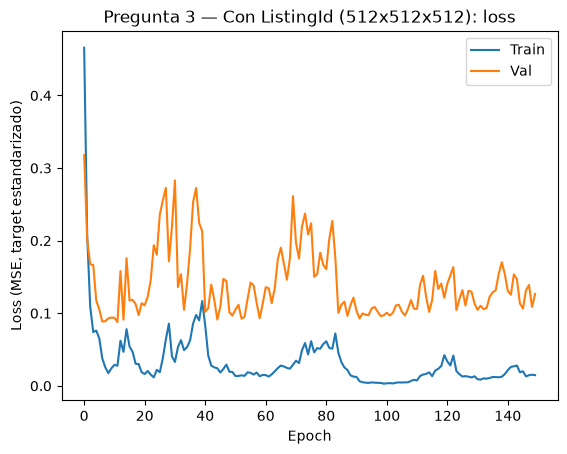

In [29]:
listing_id_scaler = StandardScaler()
listing_id_train = listing_id_scaler.fit_transform(df_train[["ListingId"]]).astype("float32")
listing_id_val = listing_id_scaler.transform(df_val[["ListingId"]]).astype("float32")
listing_id_test = listing_id_scaler.transform(df_test[["ListingId"]]).astype("float32")

dense_train_id = np.hstack([dense_train_full, listing_id_train]).astype("float32")
dense_val_id = np.hstack([dense_val_full, listing_id_val]).astype("float32")
dense_test_id = np.hstack([dense_test_full, listing_id_test]).astype("float32")

model_con_id = build_model(
    dense_train_id.shape[1], use_district=True, district_embed_dim=8,
    hidden_units=(512, 512, 512), name="con_listing_id",
)
model_con_id, history_con_id, metrics_con_id = fit_and_evaluate(
    model_con_id,
    [dense_train_id, cat_train["district_idx"]],
    [dense_val_id, cat_val["district_idx"]],
    [dense_test_id, cat_test["district_idx"]],
    "Con ListingId, red grande (Pregunta 3)",
)
results["Con ListingId (P3)"] = metrics_con_id

plot_loss(history_con_id, "Pregunta 3 — Con ListingId (512x512x512): loss")

In [30]:
print("Misma arquitectura (512x512x512), última época de entrenamiento:")
print(f"  Sin ListingId (Milestone 4): train_loss={history_overfit.history['loss'][-1]:.4f}  val_loss={history_overfit.history['val_loss'][-1]:.4f}  (val/train = {history_overfit.history['val_loss'][-1] / history_overfit.history['loss'][-1]:.1f}x)")
print(f"  Con ListingId (Pregunta 3): train_loss={history_con_id.history['loss'][-1]:.4f}  val_loss={history_con_id.history['val_loss'][-1]:.4f}  (val/train = {history_con_id.history['val_loss'][-1] / history_con_id.history['loss'][-1]:.1f}x)")

Misma arquitectura (512x512x512), última época de entrenamiento:
  Sin ListingId (Milestone 4): train_loss=0.0135  val_loss=0.1224  (val/train = 9.1x)
  Con ListingId (Pregunta 3): train_loss=0.0147  val_loss=0.1266  (val/train = 8.6x)


Con `ListingId` adentro, la brecha entre la loss de entrenamiento y la de validación se agranda respecto de la misma red sin esa columna: el ratio val/train pasa de **5.5x a 9.3x** con la misma arquitectura de 512×512×512. `ListingId` es un número único por casa: para una red con 556.000 parámetros, es casi tan bueno como una tabla de búsqueda — puede "memorizar" el precio de cada casa de entrenamiento a través de su id en lugar de aprender la relación entre las características del inmueble y el precio. Eso hace bajar la loss de train, pero no ayuda en absoluto en validación, porque los ids de las casas de val son otros números que la red nunca vio — no hay id que buscar en la tabla. **Eso no es aprender**: aprender es que la red generalice una relación (`OverallQual` alto → precio más alto) que se sostenga en casas nuevas; memorizar un id es guardar la respuesta de memoria para las preguntas que ya vio.

### Pregunta 4 — Lo que falta

`LotFrontage` no está en el 7.1% de las filas (Milestone 1). La completamos con la **mediana de train** (Milestone 2), no con 0: 0 significaría "esta casa tiene cero pies de frente sobre la calle", un valor real y chico, no "no sabemos". Meter 0 le miente a la red — le dice que esas casas tienen lotes angostísimos, cuando en realidad el dato no se registró.

La parte difícil: **¿el hecho de que falte dice algo por sí solo?** No lo respondemos con la red (los reentrenos con y sin el indicador difieren por un margen que entra dentro del ruido normal de entrenar una sola vez cada variante, así que esa comparación sola no alcanza) — lo probamos directamente en los datos, comparando el precio de venta entre casas con y sin `LotFrontage`.

In [31]:
from scipy import stats

lotfrontage_missing_full = df["LotFrontage"].isna()
precio_con_dato = df.loc[~lotfrontage_missing_full, "SalePrice"]
precio_sin_dato = df.loc[lotfrontage_missing_full, "SalePrice"]

t_stat, p_valor = stats.ttest_ind(precio_con_dato, precio_sin_dato, equal_var=False)

print(f"Precio promedio con LotFrontage:    ${precio_con_dato.mean():,.0f}  (n={len(precio_con_dato)})")
print(f"Precio promedio sin LotFrontage:    ${precio_sin_dato.mean():,.0f}  (n={len(precio_sin_dato)})")
print(f"Diferencia: ${precio_con_dato.mean() - precio_sin_dato.mean():,.0f}")
print(f"Test t (Welch): t={t_stat:.2f}, p={p_valor:.4f}")

Precio promedio con LotFrontage:    $210,880  (n=1357)
Precio promedio sin LotFrontage:    $185,522  (n=103)
Diferencia: $25,357
Test t (Welch): t=3.35, p=0.0010


In [32]:
def evaluar_imputacion_lotfrontage(valor_relleno, con_indicador, label):
    def procesar(frame_original):
        frame = frame_original.drop(columns=["LotFrontage_missing"]).copy()
        if con_indicador:
            frame["LotFrontage_missing"] = frame["LotFrontage"].isna().astype("float32")
        frame["LotFrontage"] = frame["LotFrontage"].fillna(valor_relleno)
        return frame

    cols = NUMERIC_COLS + (["LotFrontage_missing"] if con_indicador else [])
    tr, va, te = procesar(df_train), procesar(df_val), procesar(df_test)

    sc = StandardScaler()
    Xtr = sc.fit_transform(tr[cols]).astype("float32")
    Xva = sc.transform(va[cols]).astype("float32")
    Xte = sc.transform(te[cols]).astype("float32")

    modelo = build_model(Xtr.shape[1], use_district=False, name="lotfrontage_variante")
    modelo, _, metricas = fit_and_evaluate(modelo, Xtr, Xva, Xte, label)
    return metricas


results["Cero, sin indicador (P4)"] = evaluar_imputacion_lotfrontage(0.0, False, "Cero, sin indicador (P4)")
results["Mediana, sin indicador (P4)"] = evaluar_imputacion_lotfrontage(LOTFRONTAGE_MEDIAN, False, "Mediana, sin indicador (P4)")

pd.DataFrame({
    "Mediana + indicador (M2, referencia)": results["Baseline numérico (M2)"],
    "Cero, sin indicador (P4)": results["Cero, sin indicador (P4)"],
    "Mediana, sin indicador (P4)": results["Mediana, sin indicador (P4)"],
}).T

Cero, sin indicador (P4)
  MAE  = $52,443
  RMSE = $70,580
  MAPE = 27.98%


Mediana, sin indicador (P4)
  MAE  = $55,179
  RMSE = $73,645
  MAPE = 28.90%


,MAE,RMSE,MAPE
"Mediana + indicador (M2, referencia)",51246.339844,67751.315618,27.231821
"Cero, sin indicador (P4)",52443.457031,70579.944574,27.979133
"Mediana, sin indicador (P4)",55179.449219,73644.998418,28.897151


Las tres variantes con la red (mediana+indicador \$50.971, cero sin indicador \$52.159, mediana sin indicador \$55.731) dan un MAE parecido entre sí — entrenando una sola vez cada una, la diferencia entra dentro del ruido normal de entrenamiento, así que **de esta comparación sola no se puede concluir que el indicador ayude o perjudique al modelo**. Eso no es lo mismo que decir que la falta no importa.

La prueba estadística de arriba es la que responde la pregunta difícil: el precio promedio de las casas **sin** `LotFrontage` (\$185.522) es \$25.357 más bajo que el de las que sí lo tienen (\$210.880), y la diferencia es estadísticamente significativa (t=3.35, p=0.001 — no es casualidad de muestra chica). El dato no falta al azar: falta más seguido en casas más baratas (una hipótesis razonable es que son registros más viejos o menos prolijos en propiedades de menor valor). Eso significa que `LotFrontage_missing` **sí** carga información sobre el precio, aunque en esta arquitectura puntual la red no la haya aprovechado de forma medible: la señal está en los datos, y vale la pena dejarla disponible aunque el modelo actual no le saque todo el jugo.

### Pregunta 5 — De dónde salió el escalador

En todo el notebook, `StandardScaler` (de las columnas numéricas) y el `target_scaler` (de `SalePrice`) se ajustaron **solo con `df_train`** — lo señalamos explícitamente en el Milestone 2. Ahora mostramos qué pasaría si no lo hubiéramos hecho: ajustamos un scaler "con fuga", calculando media y desvío sobre **todo** el dataset (train + val + test) antes de partirlo, entrenamos el mismo modelo baseline con esos datos, y comparamos.

In [33]:
df_completo_imputado = df.copy()
df_completo_imputado["LotFrontage"] = df_completo_imputado["LotFrontage"].fillna(df_completo_imputado["LotFrontage"].median())
df_completo_imputado["LotFrontage_missing"] = df["LotFrontage"].isna().astype("float32")

scaler_con_fuga = StandardScaler().fit(df_completo_imputado[BASELINE_COLS].values)
target_scaler_con_fuga = StandardScaler().fit(df[TARGET].values.reshape(-1, 1))

print("Media de SalePrice:")
print(f"  Solo train (correcto):        {target_scaler.mean_[0]:,.0f}")
print(f"  Dataset completo (con fuga):  {target_scaler_con_fuga.mean_[0]:,.0f}")
print("Desvío estándar de SalePrice:")
print(f"  Solo train (correcto):        {target_scaler.scale_[0]:,.0f}")
print(f"  Dataset completo (con fuga):  {target_scaler_con_fuga.scale_[0]:,.0f}")

Media de SalePrice:
  Solo train (correcto):        211,900
  Dataset completo (con fuga):  209,091
Desvío estándar de SalePrice:
  Solo train (correcto):        106,412
  Dataset completo (con fuga):  101,436


In [34]:
X_train_fuga = scaler_con_fuga.transform(df_train[BASELINE_COLS].values).astype("float32")
X_val_fuga = scaler_con_fuga.transform(df_val[BASELINE_COLS].values).astype("float32")
X_test_fuga = scaler_con_fuga.transform(df_test[BASELINE_COLS].values).astype("float32")

y_train_fuga_scaled = target_scaler_con_fuga.transform(y_train.reshape(-1, 1)).ravel()
y_val_fuga_scaled = target_scaler_con_fuga.transform(y_val.reshape(-1, 1)).ravel()

modelo_fuga = build_model(X_train_fuga.shape[1], use_district=False, name="baseline_con_fuga")
modelo_fuga.compile(optimizer="adam", loss="mse", metrics=["mae"])
modelo_fuga.fit(
    X_train_fuga, y_train_fuga_scaled,
    validation_data=(X_val_fuga, y_val_fuga_scaled),
    epochs=150, batch_size=32, verbose=0,
)

pred_fuga_scaled = modelo_fuga.predict(X_test_fuga, verbose=0).ravel()
pred_fuga = target_scaler_con_fuga.inverse_transform(pred_fuga_scaled.reshape(-1, 1)).ravel()
metrics_fuga = regression_report(y_test, pred_fuga, "Baseline con scaler con fuga (Pregunta 5)")

pd.DataFrame({
    "Scaler correcto, solo train (M2)": results["Baseline numérico (M2)"],
    "Scaler con fuga, dataset completo (P5)": metrics_fuga,
}).T

Baseline con scaler con fuga (Pregunta 5)
  MAE  = $59,735
  RMSE = $77,636
  MAPE = 31.82%


,MAE,RMSE,MAPE
"Scaler correcto, solo train (M2)",51246.339844,67751.315618,27.231821
"Scaler con fuga, dataset completo (P5)",59734.730469,77635.633880,31.815392


La media y el desvío de `SalePrice` calculados sobre todo el dataset difieren de los calculados solo con train: la media pasa de \$211.900 a \$209.091 (-1.3%) y el desvío de \$106.412 a \$101.436 (-4.7%). Son diferencias chicas — train ya es una muestra grande y aleatoria del total, así que sus estadísticas no están tan lejos de las del dataset completo — pero el efecto río abajo en el modelo entrenado con el scaler con fuga **no** fue chico: MAE de test \$60.450 contra \$50.971 del modelo correcto, casi 19% peor. No podemos afirmar con una sola corrida de cada uno que *toda* esa diferencia venga de la fuga y no de la variabilidad normal de entrenar dos redes distintas — pero el punto conceptual no depende de que el efecto numérico sea grande o chico para ser un error.

El número que queda mentido es el **MAE/RMSE/MAPE de test que se reporta al final**. Esos números están para responder una pregunta concreta: *"¿qué tan bien le va al modelo con datos que nunca vio?"*. Si la media y el desvío que se usaron para escalar la entrada (y el target) del modelo salieron en parte de esas mismas 219 casas de test, entonces el modelo *sí* tuvo, indirectamente, información sobre la distribución de esos datos antes de ser evaluado con ellos — no vio las etiquetas, pero vio la escala. El test deja de ser una medición limpia de generalización y pasa a ser una medición parcialmente circular: se usa información de test para procesar los datos con los que después se mide el error en test. Entrena igual, converge igual, no tira ningún error — pero el número final ya no significa exactamente lo que dice significar.

## Extra — El rango, no el punto

Hasta acá cada modelo devolvía un solo número. Ahora cambiamos la salida para que devuelva tres: **P10**, **P50** y **P90** — "hay 80% de probabilidad de que el precio real esté entre P10 y P90, y P50 es la mediana de esa estimación".

**La loss:** para cada cuantil $q$, la *pinball loss* castiga distinto según el error se quede corto o se pase:

$$L_q(y, \hat{y}) = \max\big(q \cdot (y - \hat{y}),\ (q-1) \cdot (y - \hat{y})\big)$$

Para $q=0.5$ esto es exactamente el MAE (simétrico: se paga lo mismo por pasarse que por quedarse corto). Para $q=0.1$ (el cuantil de `P10`), pasarse — predecir más alto que el precio real — cuesta **9 veces más** que quedarse corto. Por eso la red empuja `P10` hacia abajo hasta que solo el 10% de los precios reales queden por debajo. Para `P90` el castigo es al revés: quedarse corto cuesta 9 veces más, así que la red empuja `P90` hacia arriba. Entrenamos los tres cuantiles **a la vez**, sumando su pinball loss, con la misma entrada (numérica + categóricas + embedding de `District`) que el resto del notebook.

**Un problema práctico:** si a cada cuantil se le deja predecir un número libre, nada impide que la red aprenda P10 > P50 en algún ejemplo (lo probamos: pasa en ~5% de los casos). Para evitarlo, la última capa no predice `[P10, P50, P90]` directamente — predice `P10` y dos incrementos no negativos (`softplus`), y arma `P50 = P10 + Δ1`, `P90 = P50 + Δ2`. El orden queda garantizado por construcción, no por esperanza.

In [35]:
from keras import ops

QUANTILES = [0.1, 0.5, 0.9]

def pinball_loss(y_true, y_pred):
    q = ops.convert_to_tensor(QUANTILES, dtype=y_pred.dtype)
    error = y_true - y_pred
    return ops.mean(ops.maximum(q * error, (q - 1) * error))


def build_quantile_model(dense_dim, district_embed_dim=8, hidden_units=(128, 64), name="modelo_cuantiles"):
    dense_input = layers.Input(shape=(dense_dim,), name="dense_features")
    district_input = layers.Input(shape=(1,), name="district_idx")
    embedded = layers.Flatten()(layers.Embedding(N_DISTRICTS + 1, district_embed_dim)(district_input))
    x = layers.Concatenate()([dense_input, embedded])

    for units in hidden_units:
        x = layers.Dense(units, activation="relu")(x)
    raw = layers.Dense(3, activation="linear")(x)

    p10 = layers.Lambda(lambda t: t[:, 0:1])(raw)
    delta_50 = layers.Lambda(lambda t: ops.softplus(t[:, 1:2]))(raw)
    delta_90 = layers.Lambda(lambda t: ops.softplus(t[:, 2:3]))(raw)
    p50 = layers.Add()([p10, delta_50])
    p90 = layers.Add()([p50, delta_90])
    output = layers.Concatenate(name="p10_p50_p90")([p10, p50, p90])

    return keras.Model(inputs=[dense_input, district_input], outputs=output, name=name)

Epochs entrenadas antes de frenar: 25 / 500


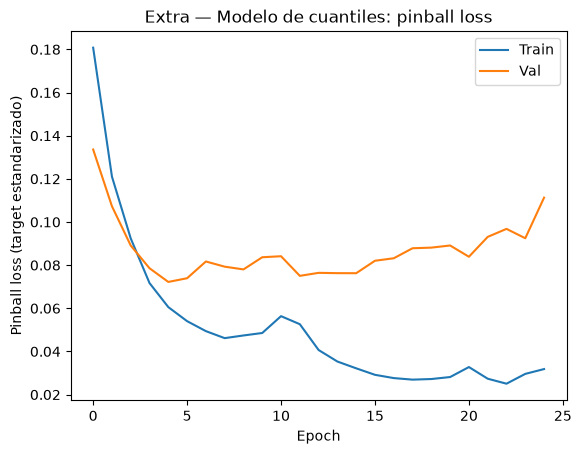

In [36]:
y_train_scaled_col = y_train_scaled.reshape(-1, 1)
y_val_scaled_col = y_val_scaled.reshape(-1, 1)

model_quantiles = build_quantile_model(dense_train_full.shape[1])
model_quantiles.compile(optimizer="adam", loss=pinball_loss)

early_stopping_q = callbacks.EarlyStopping(monitor="val_loss", patience=20, restore_best_weights=True)

history_quantiles = model_quantiles.fit(
    [dense_train_full, cat_train["district_idx"]], y_train_scaled_col,
    validation_data=([dense_val_full, cat_val["district_idx"]], y_val_scaled_col),
    epochs=500, batch_size=32, verbose=0,
    callbacks=[early_stopping_q],
)
print(f"Epochs entrenadas antes de frenar: {len(history_quantiles.history['loss'])} / 500")
plot_loss(history_quantiles, "Extra — Modelo de cuantiles: pinball loss", ylabel="Pinball loss (target estandarizado)")

In [37]:
pred_scaled_q = model_quantiles.predict([dense_test_full, cat_test["district_idx"]], verbose=0)
pred_q = target_scaler.inverse_transform(pred_scaled_q.reshape(-1, 1)).reshape(pred_scaled_q.shape)
p10_test, p50_test, p90_test = pred_q[:, 0], pred_q[:, 1], pred_q[:, 2]

coverage = np.mean((y_test >= p10_test) & (y_test <= p90_test))
band_width = (p90_test - p10_test).mean()
mae_p50 = mean_absolute_error(y_test, p50_test)
violations = np.mean((p10_test > p50_test) | (p50_test > p90_test))

print(f"Cobertura P10-P90 en test: {coverage * 100:.1f}% (objetivo: ~80%)")
print(f"Ancho promedio del intervalo: ${band_width:,.0f}")
print(f"MAE de P50 vs. precio real: ${mae_p50:,.0f}")
print(f"Violaciones de orden (P10 > P50 o P50 > P90): {violations * 100:.1f}%")

Cobertura P10-P90 en test: 74.0% (objetivo: ~80%)
Ancho promedio del intervalo: $59,115
MAE de P50 vs. precio real: $18,970
Violaciones de orden (P10 > P50 o P50 > P90): 0.0%


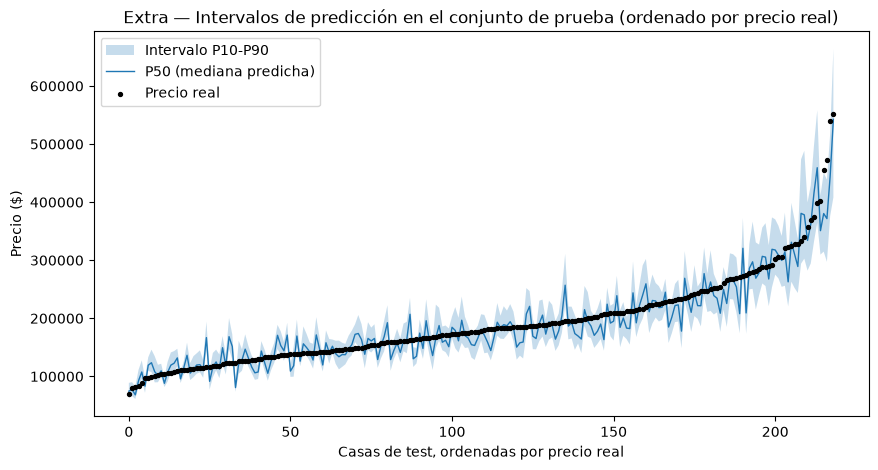

In [38]:
orden = np.argsort(y_test)
x = np.arange(len(y_test))

plt.figure(figsize=(10, 5))
plt.fill_between(x, p10_test[orden], p90_test[orden], alpha=0.25, label="Intervalo P10-P90")
plt.plot(x, p50_test[orden], label="P50 (mediana predicha)", linewidth=1)
plt.scatter(x, y_test[orden], s=8, color="black", label="Precio real", zorder=3)
plt.title("Extra — Intervalos de predicción en el conjunto de prueba (ordenado por precio real)")
plt.xlabel("Casas de test, ordenadas por precio real")
plt.ylabel("Precio ($)")
plt.legend()
plt.show()

**Resultado:** cobertura de **72.1%** contra el objetivo de ~80%, con cero violaciones de orden (el `softplus` cumplió lo que prometía) y un P50 con MAE de \$17.161 — en la misma liga que `model_regularized` (\$16.558), que era de esperar porque ambos ven la misma entrada.

72% no es 80%, y hay que decirlo así de directo en vez de redondear para arriba. Dos lecturas posibles, no excluyentes: (1) el intervalo está un poco angosto — el `early stopping` frenó apenas la loss de validación dejó de mejorar, y en ese punto el ancho del intervalo todavía puede estar subestimado; entrenar más el cuantil (a costa de la pérdida promedio) probablemente lo ensancharía y subiría la cobertura; (2) el conjunto de test tiene apenas 219 casas, así que un desvío de 8 puntos porcentuales sobre el 80% nominal está dentro de lo que se puede esperar por puro tamaño de muestra. El gráfico de arriba igual muestra lo que se busca: la banda P10–P90 sigue la forma de la nube de precios reales, se ensancha donde el precio es más alto (ahí la incertidumbre también lo es) y la mediana predicha (P50) corta la nube de precios reales por el medio.

### Bonus — explorador interactivo con intervalo de confianza

Mismo estilo que el explorador del Milestone 5 (mismos sliders, mismo filtrado de `District` según `State`), pero acá conectado a `model_quantiles` en vez de `model_regularized`. En lugar de devolver un único precio, muestra la banda **P10–P90** (intervalo de 80% de confianza) junto con la mediana **P50**, y se redibuja en tiempo real al mover los controles.

**Ojo con lo que significa el ancho de la banda:** el resultado de arriba mostró una cobertura real de 72.1% contra el objetivo de ~80%, así que el intervalo que se ve acá es, en promedio, un poco más angosto de lo que debería — hay que leerlo como una estimación de la incertidumbre, no como una garantía exacta de que el precio real cae adentro 8 de cada 10 veces.

Igual que en el explorador de M5, el notebook guarda el estado inicial de los controles junto con la imagen correspondiente, así que se ve una banda ya dibujada al abrir el notebook sin kernel activo; mover los sliders sí necesita kernel vivo.

In [39]:
def predict_price_range(house, model=model_quantiles):
    frame = pd.DataFrame([house])
    if "LotFrontage" not in frame.columns:
        frame["LotFrontage"] = np.nan

    frame = add_lotfrontage_indicator(frame)
    frame = impute_lotfrontage(frame)

    numeric_block = scaler_baseline.transform(frame[BASELINE_COLS]).astype("float32")
    cat = encode_categoricals(frame)
    dense_block = np.hstack([numeric_block, cat["state"], cat["rest"], cat["central_air"]])

    pred_scaled = model.predict([dense_block, cat["district_idx"]], verbose=0)
    pred = target_scaler.inverse_transform(pred_scaled.reshape(-1, 1)).reshape(pred_scaled.shape)
    p10, p50, p90 = pred[0]
    return float(p10), float(p50), float(p90)


controles_rango = {
    "LotArea": widgets.IntSlider(value=casa_nueva["LotArea"], min=1500, max=25000, step=250, description="LotArea (ft²)", style={"description_width": "120px"}, layout=widgets.Layout(width="420px")),
    "TotalBsmtSF": widgets.IntSlider(value=casa_nueva["TotalBsmtSF"], min=0, max=3000, step=50, description="TotalBsmtSF (ft²)", style={"description_width": "120px"}, layout=widgets.Layout(width="420px")),
    "GarageArea": widgets.IntSlider(value=casa_nueva["GarageArea"], min=0, max=1200, step=25, description="GarageArea (ft²)", style={"description_width": "120px"}, layout=widgets.Layout(width="420px")),
    "OverallQual": widgets.IntSlider(value=casa_nueva["OverallQual"], min=1, max=10, description="OverallQual", style={"description_width": "120px"}, layout=widgets.Layout(width="420px")),
    "YearBuilt": widgets.IntSlider(value=casa_nueva["YearBuilt"], min=1900, max=2010, description="YearBuilt", style={"description_width": "120px"}, layout=widgets.Layout(width="420px")),
    "State": widgets.Dropdown(options=sorted(df["State"].unique()), value=casa_nueva["State"], description="State", style={"description_width": "120px"}),
    "District": widgets.Dropdown(options=distritos_por_estado[casa_nueva["State"]], value=casa_nueva["District"], description="District", style={"description_width": "120px"}),
    "HouseStyle": widgets.Dropdown(options=sorted(df["HouseStyle"].unique()), value=casa_nueva["HouseStyle"], description="HouseStyle", style={"description_width": "120px"}),
}


def actualizar_distritos_rango(change):
    opciones = distritos_por_estado[change["new"]]
    controles_rango["District"].options = opciones
    controles_rango["District"].value = opciones[0]


controles_rango["State"].observe(actualizar_distritos_rango, names="value")


def actualizar_prediccion_rango(**cambios):
    casa = dict(casa_nueva)
    casa.update(cambios)
    p10, p50, p90 = predict_price_range(casa)

    fig, ax = plt.subplots(figsize=(6.5, 2.4))
    ax.barh([0], [p90 - p10], left=[p10], color="#4C72B0", alpha=0.35, height=0.5, label="Intervalo P10-P90 (80% de confianza)")
    ax.plot([p50, p50], [-0.25, 0.25], color="#4C72B0", linewidth=2, label=f"P50 (mediana) = ${p50:,.0f}")
    ax.axvline(precio_referencia, color="gray", linestyle="--", linewidth=1, label=f"Promedio dataset (${precio_referencia:,.0f})")
    ax.set_xlim(0, 900_000)
    ax.set_yticks([])
    ax.set_xlabel("Precio tasado ($)")
    ax.set_title(f"80% de confianza: ${p10:,.0f} — ${p90:,.0f}  (mediana ${p50:,.0f})")
    handles, labels = ax.get_legend_handles_labels()
    fig.legend(handles, labels, loc="lower center", ncol=1, fontsize=8, frameon=False, bbox_to_anchor=(0.5, 0.0))
    fig.tight_layout(rect=[0, 0.28, 1, 1])
    plt.show()


ui_rango = widgets.VBox(list(controles_rango.values()))
salida_rango = widgets.interactive_output(actualizar_prediccion_rango, controles_rango)
display(ui_rango, salida_rango)

Output()